# Fiscal policy

This notebook compares fiscal responses in heterogeneous-agent, representative-agent, and two-agent models. The heterogeneous-agent model uses the same low-asset calibration as the other early lecture notebooks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sim_steady_state_fast as sim
import sim_fake_news
from calibration import make_calibration

In [2]:
# for plotting: uncomment second line to get plots with exact style
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'figure.figsize': (6, 3)})
plt.rcParams.update({'text.usetex': True, 'font.serif': 'Palatino'})

## Calibration

Load the low-asset calibration from lecture 1, targeting assets equal to 100% of annual GDP. This is the bond-only calibration used in the early fiscal and monetary notebooks.

In [3]:
calib, e = make_calibration(lowA=True)
r = calib['r']
ss = sim.steady_state(**calib)

assert np.isclose(ss['A'] / 4, 1) # targeted A=100% of annual GDP

## Intertemporal MPCs

We first calculate the consumption Jacobian with respect to the after-tax wage $Z$. Since household income is $y = Z e$, a unit change in $Z_s$ changes income in proportion to the income vector `e`. We interpret the consumption Jacobian $M$ as the matrix of intertemporal MPCs.

### Heterogeneous-agent model

In [4]:
T = 400
J = sim_fake_news.jacobian(ss, {'Z': {'y': e}}, T=T)
M, A = J['C']['Z'], J['A']['Z']
assert np.isclose(M[0, 0], 0.2) # targeted impact weighted MPC = 0.2

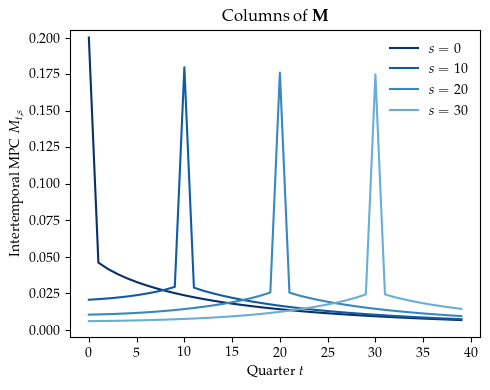

In [5]:
colors = plt.cm.Blues(np.linspace(0.5, 1, 4)[::-1])
plt.figure(figsize=(5, 4))
for i, s in enumerate([0, 10, 20, 30]):
    plt.plot(M[:40, s], label=fr'$s={s}$', color=colors[i])
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'Intertemporal MPC $M_{t,s}$')
plt.title(r'Columns of $\mathbf{M}$')
plt.legend(frameon=False)
plt.tight_layout()
plt.ylim(-0.005, 0.205)
plt.savefig('figures/lecture2_impc.pdf', transparent=True, bbox_inches='tight')

### Representative-agent benchmark

For a representative agent with the same interest rate, a one-time transfer is spread across time in proportion to the present-value weights $q_s = (1+r)^{-s}$.

In [6]:
q = (1 + r) ** -np.arange(T)
M_ra = np.outer(np.ones(T), q) / np.sum(q)

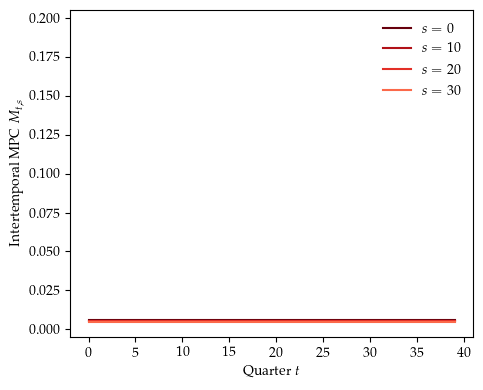

In [7]:
colors = plt.cm.Reds(np.linspace(0.5, 1, 4)[::-1])
plt.figure(figsize=(5, 4))
for i, s in enumerate([0, 10, 20, 30]):
    plt.plot(M_ra[:40, s], label=fr'$s={s}$', color=colors[i])
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'Intertemporal MPC $M_{t,s}$')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/lecture2_impc_ra.pdf', transparent=True, bbox_inches='tight')
plt.ylim(-0.005, 0.205)
plt.savefig('figures/lecture2_impc_ra_zoomedout.pdf', transparent=True, bbox_inches='tight')

### Two-agent benchmark

The two-agent model combines hand-to-mouth households with the representative-agent response. We choose the hand-to-mouth share `lam` so that the impact MPC equals 0.20.

In [8]:
lam = (0.20 - M_ra[0, 0]) / (1 - M_ra[0, 0])
M_ta = lam * np.eye(T) + (1 - lam) * M_ra
lam

np.float64(0.19536666234490316)

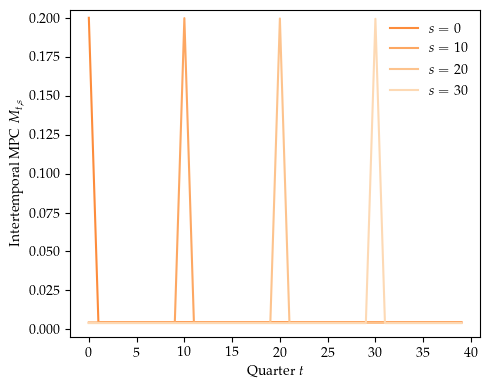

In [9]:
colors = plt.cm.Oranges(np.linspace(0.2, 0.5, 4)[::-1])
plt.figure(figsize=(5, 4))
for i, s in enumerate([0, 10, 20, 30]):
    plt.plot(M_ta[:40, s], label=fr'$s={s}$', color=colors[i])
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'Intertemporal MPC $M_{t,s}$')
plt.legend(frameon=False)
plt.tight_layout()
plt.ylim(-0.005, 0.205)
plt.savefig('figures/lecture2_impc_ta_zoomedout.pdf', transparent=True, bbox_inches='tight')

Compare the impact columns of the three models:

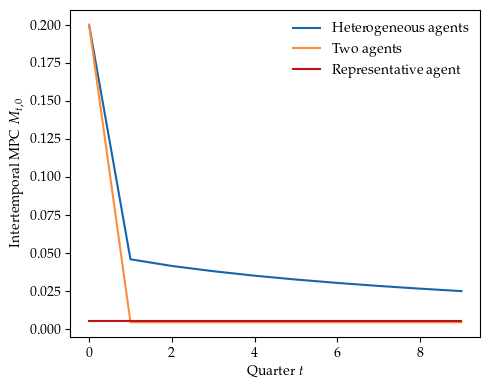

In [10]:
plt.figure(figsize=(5, 4))
plt.plot(M[:10, 0], label='Heterogeneous agents', color=plt.cm.Blues(0.8))
plt.plot(M_ta[:10, 0], label='Two agents', color=plt.cm.Oranges(0.5))
plt.plot(M_ra[:10, 0], label='Representative agent', color=plt.cm.Reds(0.8))
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'Intertemporal MPC $M_{t,0}$')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/lecture2_impc_comparison.pdf', transparent=True, bbox_inches='tight')

## Deficit-financed tax cut

Now consider a negative AR(1) impulse to desired taxes. The government gradually brings debt back toward its steady-state target, so the realized tax path `dT` differs from the initial desired tax-cut shock.

In [11]:
rho_B, rho = 0.975, 0.9

dT_shock = -rho**np.arange(T)
dB = np.empty_like(dT_shock)
dB[0] = -dT_shock[0]
for t in range(1, T):
    dB[t] = rho_B * dB[t-1] - dT_shock[t]

dT = np.empty_like(dT_shock)
dT[0] = -dB[0]
dT[1:] = -dB[1:] + (1 + r) * dB[:-1]

# The small residual is truncation error from using a finite horizon T.
print('NPV of tax cut shock:', np.sum(dT * (1 + r) ** (-np.arange(T))))

NPV of tax cut shock: -7.286624256169771e-05


Plot the tax path and the associated debt path:

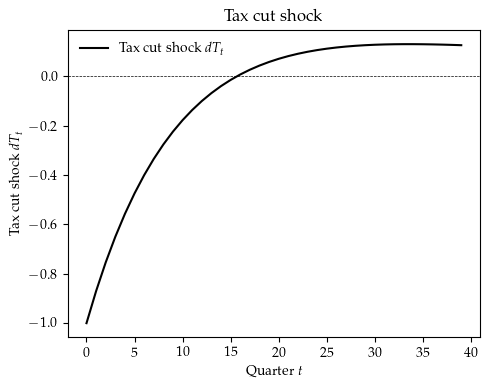

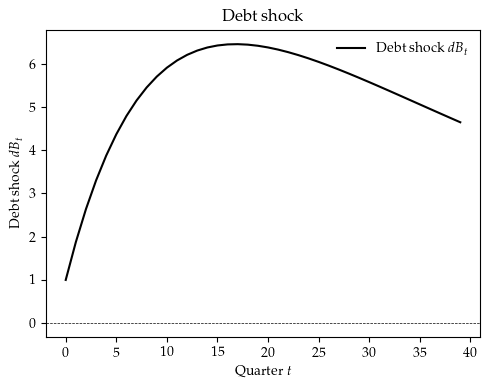

In [12]:
plt.figure(figsize=(5, 4))
plt.plot(dT[:40], label=r'Tax cut shock $dT_t$', color='k')
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'Tax cut shock $dT_t$')
plt.title('Tax cut shock')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/lecture2_tax_cut_shock.pdf', transparent=True, bbox_inches='tight')

plt.figure(figsize=(5, 4))
plt.plot(dB[:40], label=r'Debt shock $dB_t$', color='k')
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'Debt shock $dB_t$')
plt.title('Debt shock')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/lecture2_debt_shock.pdf', transparent=True, bbox_inches='tight')

## Output responses

In the heterogeneous-agent model, asset-market clearing gives the output response $dY = A^{-1} dB + dT$. The representative-agent response is zero by Ricardian equivalence, while the two-agent response comes from the hand-to-mouth households' exposure to the tax path.

In [ ]:
dY = {'ra': np.zeros(T),
      'ta': lam/(1 - lam) * (-dT),
      'ha': np.linalg.solve(A, dB) + dT}

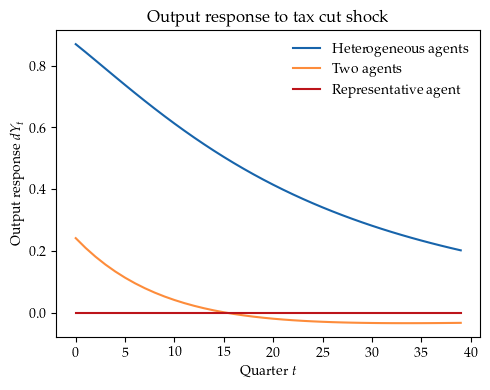

In [14]:
plt.figure(figsize=(5, 4))
plt.plot(dY['ha'][:40], label='Heterogeneous agents', color=plt.cm.Blues(0.8))
plt.plot(dY['ta'][:40], label='Two agents', color=plt.cm.Oranges(0.5))
plt.plot(dY['ra'][:40], label='Representative agent', color=plt.cm.Reds(0.8))
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'Output response $dY_t$')
plt.title('Output response to tax cut shock')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('figures/lecture2_output_response.pdf', transparent=True, bbox_inches='tight')